# Learning Lorenz System Using Different Methods
This notebook implements the fourth-order Runge-Kutta (RK4) and other three methods to simulate the Lorenz system and generate reference trajectories.
1. RK4 (Numerical)
2. Neural Network (Regression)
3. Neural ODE
4. PINN (Two Loss Stages, Data Loss + Physical Loss)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [2]:
# parameters
sigma = 10.0
rho   = 28.0
beta  = 8.0 / 3.0

def lorenz(u):
    x, y, z = u
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ])

# rk4 single step
def rk4_step(f, u, dt):
    k1 = f(u)
    k2 = f(u + dt/2 * k1)
    k3 = f(u + dt/2 * k2)
    k4 = f(u + dt   * k3)
    return u + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

# run simulation
def simulate(u0, t_span, dt):
    steps = int((t_span[1] - t_span[0]) / dt)
    t = np.linspace(t_span[0], t_span[1], steps)
    traj = np.zeros((steps, 3))
    traj[0] = u0
    for i in range(1, steps):
        traj[i] = rk4_step(lorenz, traj[i-1], dt)
    return t, traj

In [3]:
u0 = np.array([1.0, 1.0, 1.0])
dt = 0.01
t_span = (0, 50)

t, traj = simulate(u0, t_span, dt)
x, y, z = traj[:, 0], traj[:, 1], traj[:, 2]



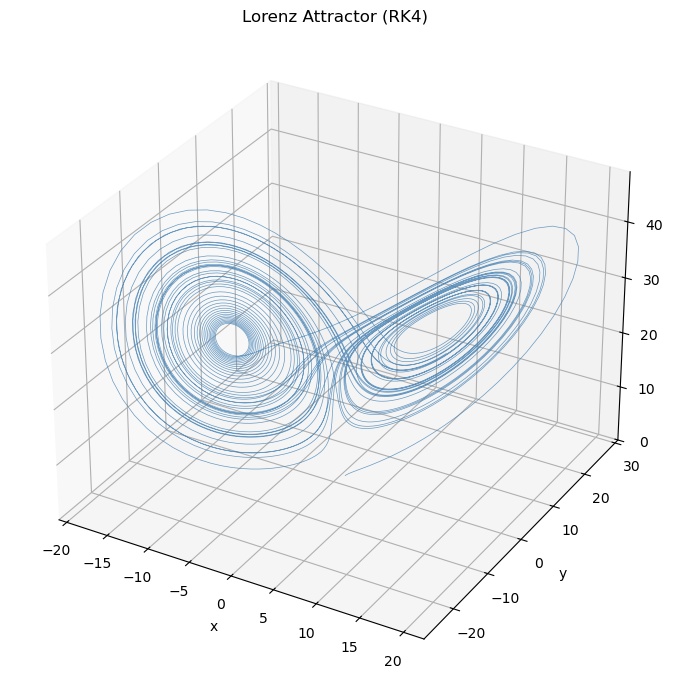

In [4]:
# 3d attractor
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.5, alpha=0.8, color='steelblue')
ax.set_title('Lorenz Attractor (RK4)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.savefig('lorenz_attractor_3d.png', dpi=150)
plt.show()




In [5]:
# store the data here, for model training
np.save('lorenz_data.npy', np.column_stack([t, traj]))

So the plot is as follow:
1. X is the intencity of convection.
    "Positive": Convectino is moving in the same direction
    "Negative": Convection is moving in reverse direction as comparison to positive
    "Bouncing back & forth": Direction is changing

2. Y is the horizontal temperature differences: It bounces back & forth since they affect each other

3. Z is the vertical temperature differences: It is always POSITIVE (It is a physical value which is always >= 0, the range is approximately between: 5 < z < 45)

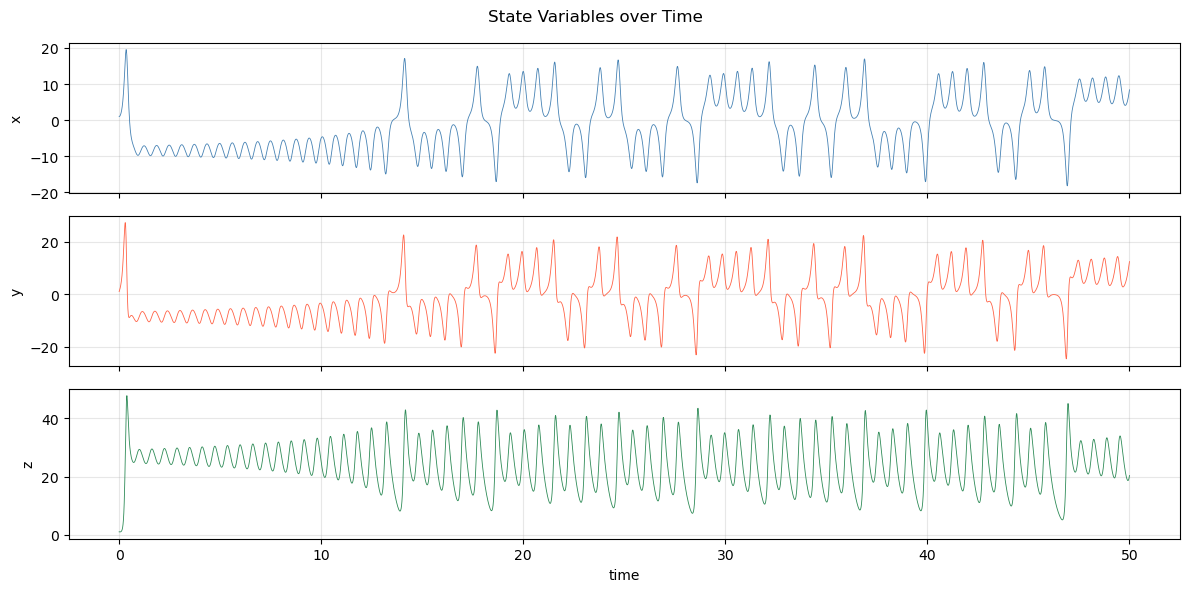

In [6]:
# x y z over time
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for ax, label, color, d in zip(axes, ['x','y','z'], ['steelblue','tomato','seagreen'], [x,y,z]):
    ax.plot(t, d, lw=0.6, color=color)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('State Variables over Time')
plt.tight_layout()
plt.savefig('lorenz_timeseries.png', dpi=150)
plt.show()


Two simulations, basically identical starting points:

- Blue: starts at x = 1
- Red: starts at x = 1.00001

The difference is 0.00001 — basically nothing.

Look what happens — up until around t=20 the two lines are completely on top of each other, you can't even tell them apart. Then they start to split. By t=30 they're totally different, one going up while the other goes down.

This is the butterfly effect in action. The system is so sensitive that even a microscopic difference in where you start leads to completely different behavior later on. This is also why weather forecasts beyond a few days are basically useless — not because the computers aren't good enough, but because the atmosphere behaves the same way.

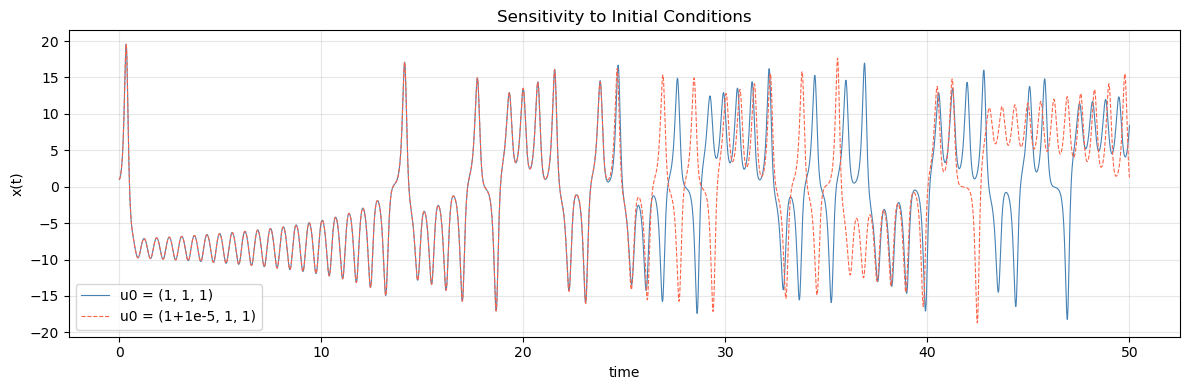

In [7]:

# sensitivity to initial conditions
_, traj2 = simulate(np.array([1.0 + 1e-5, 1.0, 1.0]), t_span, dt)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, x,          lw=0.8, color='steelblue', label='u0 = (1, 1, 1)')
ax.plot(t, traj2[:,0], lw=0.8, color='tomato', linestyle='--', label='u0 = (1+1e-5, 1, 1)')
ax.set_xlabel('time'); ax.set_ylabel('x(t)')
ax.set_title('Sensitivity to Initial Conditions')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lorenz_sensitivity.png', dpi=150)
plt.show()

## Solution: Pure Neural Network: Regression

In [2]:
import torch
import torch.nn as nn

## This is the long-term prediction usin regression

epoch 0, loss 266.2344
epoch 100, loss 83.1285
epoch 200, loss 65.9117
epoch 300, loss 64.6760
epoch 400, loss 64.4530
epoch 500, loss 64.2819
epoch 600, loss 64.1467
epoch 700, loss 64.0273
epoch 800, loss 63.9158
epoch 900, loss 63.8183
epoch 1000, loss 63.7352
epoch 1100, loss 63.6651
epoch 1200, loss 63.6060
epoch 1300, loss 63.5567
epoch 1400, loss 63.5157
epoch 1500, loss 63.4811
epoch 1600, loss 63.4512
epoch 1700, loss 63.4249
epoch 1800, loss 63.4015
epoch 1900, loss 63.3804


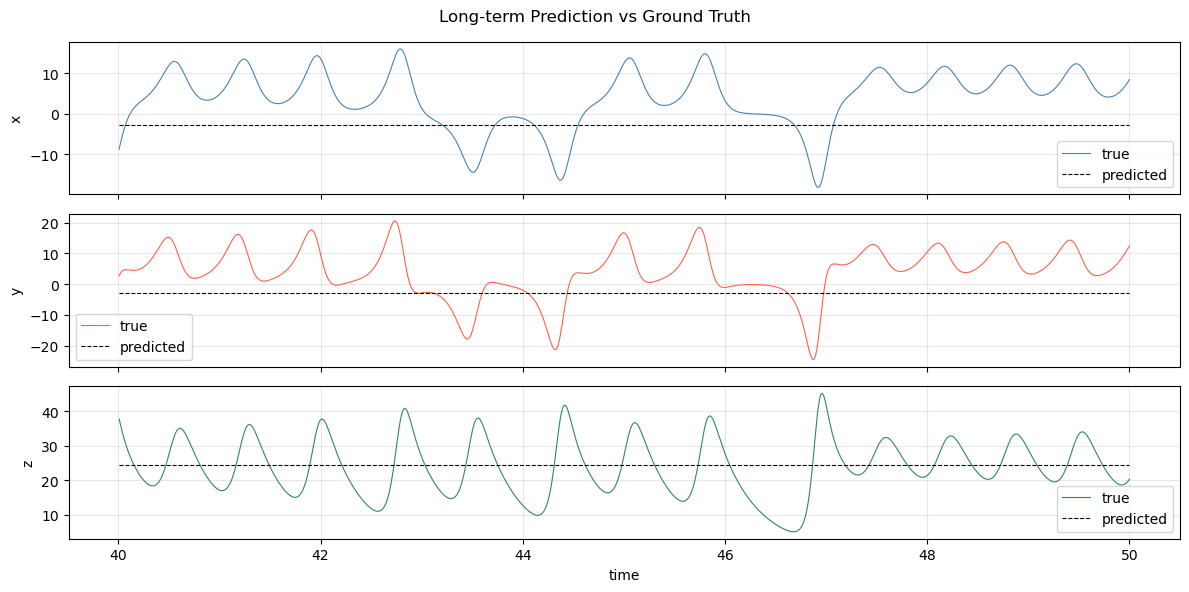

In [30]:
# long-term prediction: t -> (x, y, z)
data = np.load('lorenz_data.npy')
t    = data[:, 0].astype(np.float32)
traj = data[:, 1:].astype(np.float32)

split = int(len(t) * 0.8)
X_train = torch.tensor(t[:split]).unsqueeze(1)
y_train = torch.tensor(traj[:split])
X_test  = torch.tensor(t[split:]).unsqueeze(1)
y_test  = torch.tensor(traj[split:])

model_long = nn.Sequential(
    nn.Linear(1, 64), nn.Tanh(),
    nn.Linear(64, 256), nn.Tanh(),
    nn.Linear(256, 128), nn.Tanh(),
    nn.Linear(128, 3)
)

optimizer = torch.optim.Adam(model_long.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

for epoch in range(2000):
    pred = model_long(X_train)
    loss = loss_fn(pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'epoch {epoch}, loss {loss.item():.4f}')

# plot
model_long.eval()
with torch.no_grad():
    pred_test = model_long(X_test).numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t[split:], y_test[:, i].numpy(), lw=0.8, color=color, label='true')
    axes[i].plot(t[split:], pred_test[:, i],      lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('Long-term Prediction vs Ground Truth')
plt.tight_layout()
plt.savefig('nn_longterm.png', dpi=150)
plt.show()

## This is the prediction based on step (Predicting next few steps using regression)

In [40]:
data = np.load('lorenz_data.npy')
traj = data[:, 1:].astype(np.float32)

# input: current state, output: next 3 steps
X = torch.tensor(traj[:-3])
y = torch.tensor(np.concatenate([traj[1:-2], traj[2:-1], traj[3:]], axis=1))

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# time values aligned with X (for plotting)
t_all  = data[:-3, 0].astype(np.float32)
t_test = t_all[split:]


In [41]:
data = np.load('lorenz_data.npy')
print("shape:", data.shape)
print("\nfirst 5 rows (t, x, y, z):")
print(data[:20])

shape: (5000, 4)

first 5 rows (t, x, y, z):
[[0.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00]
 [1.00020004e-02 1.01256719e+00 1.25991780e+00 9.84890972e-01]
 [2.00040008e-02 1.04882371e+00 1.52399713e+00 9.73114220e-01]
 [3.00060012e-02 1.10720885e+00 1.79830989e+00 9.65158951e-01]
 [4.00080016e-02 1.18686802e+00 2.08854014e+00 9.61737225e-01]
 [5.00100020e-02 1.28755706e+00 2.40015446e+00 9.63806064e-01]
 [6.00120024e-02 1.40957066e+00 2.73854561e+00 9.72608170e-01]
 [7.00140028e-02 1.55369006e+00 3.10915397e+00 9.89731122e-01]
 [8.00160032e-02 1.72114638e+00 3.51756946e+00 1.01718652e+00]
 [9.00180036e-02 1.91359620e+00 3.96961501e+00 1.05751186e+00]
 [1.00020004e-01 2.13310654e+00 4.47141065e+00 1.11389892e+00]
 [1.10022004e-01 2.38214626e+00 5.02941495e+00 1.19035373e+00]
 [1.20024005e-01 2.66358091e+00 5.65043790e+00 1.29189350e+00]
 [1.30026005e-01 2.98066758e+00 6.34161545e+00 1.42478688e+00]
 [1.40028006e-01 3.33704533e+00 7.11033123e+00 1.59684333e+00]
 [1.500300

In [42]:
model = nn.Sequential(
    nn.Linear(3, 64),  nn.Tanh(),
    nn.Linear(64, 256), nn.Tanh(),
    nn.Linear(256, 128), nn.Tanh(),
    nn.Linear(128, 9)   # 3 future steps × 3 coords
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

for epoch in range(2000):
    pred = model(X_train)
    loss = loss_fn(pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'epoch {epoch}, loss {loss.item():.4f}')


epoch 0, loss 265.0771
epoch 100, loss 84.1360
epoch 200, loss 37.9793
epoch 300, loss 26.0480
epoch 400, loss 13.5148
epoch 500, loss 7.2111
epoch 600, loss 4.2826
epoch 700, loss 2.7016
epoch 800, loss 1.7989
epoch 900, loss 1.2519
epoch 1000, loss 0.9082
epoch 1100, loss 0.6851
epoch 1200, loss 0.5326
epoch 1300, loss 0.4601
epoch 1400, loss 0.3422
epoch 1500, loss 0.2813
epoch 1600, loss 0.2354
epoch 1700, loss 0.2017
epoch 1800, loss 0.1697
epoch 1900, loss 0.1460


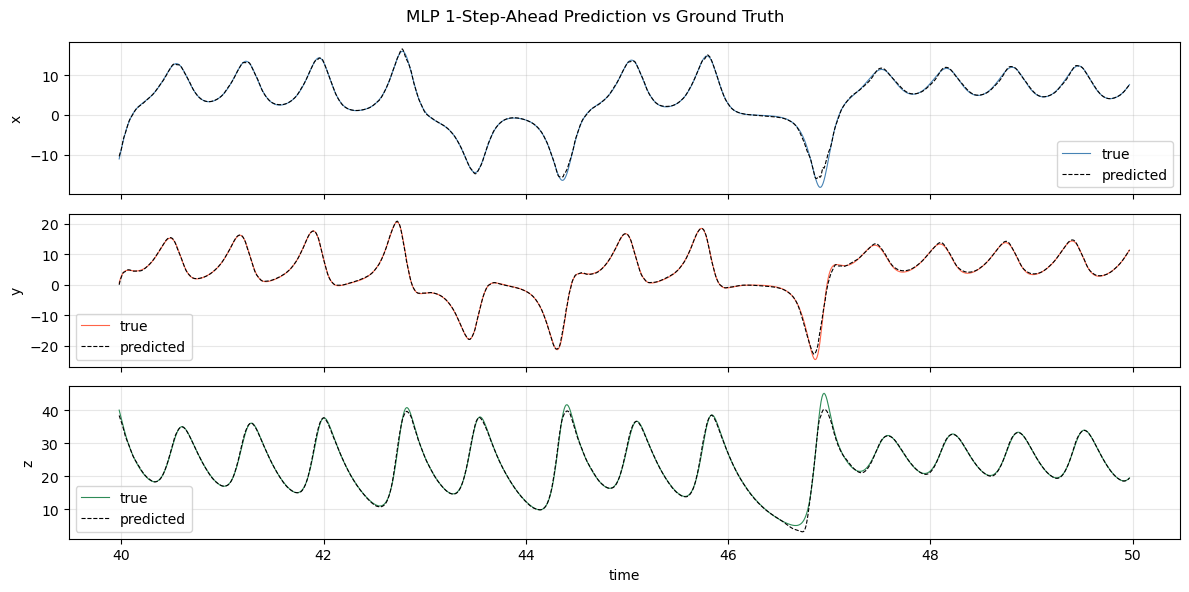

In [44]:
model.eval()
with torch.no_grad():
    pred_test = model(X_test).numpy()  # shape (N_test, 9)

# compare 1-step-ahead prediction vs true next state
true_next  = y_test[:, :3].numpy()    # first predicted step (x, y, z)
pred_next  = pred_test[:, :3]

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t_test, true_next[:, i], lw=0.8, color=color, label='true')
    axes[i].plot(t_test, pred_next[:, i], lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('MLP 1-Step-Ahead Prediction vs Ground Truth')
plt.tight_layout()
plt.savefig('nn_prediction.png', dpi=150)
plt.show()


In [17]:
from torchdiffeq import odeint

data = np.load('lorenz_data.npy')
t    = torch.tensor(data[:, 0], dtype=torch.float32)
traj = torch.tensor(data[:, 1:], dtype=torch.float32)

# normalize data
mean = traj.mean(dim=0)
std  = traj.std(dim=0)
traj_norm = (traj - mean) / std


In [20]:
# neural network that learns f(u) = du/dt
class ODEFunc(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64), nn.Tanh(),
            nn.Linear(64, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128, 3)
        )
    def forward(self, t, u):
        return self.net(u)

start = 2000  # t=20
end   = 2050  # t=20.5


t_train    = t[start:end]
traj_train = traj_norm[start:end]

func      = ODEFunc()
optimizer = torch.optim.Adam(func.parameters(), lr=1e-3)

for epoch in range(3000):
    u_pred = odeint(func, traj_train[0], t_train, method='rk4')
    loss   = nn.MSELoss()(u_pred, traj_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f'epoch {epoch}, loss {loss.item():.4f}')

epoch 0, loss 1.3999
epoch 1, loss 1.2284
epoch 2, loss 1.0703
epoch 3, loss 0.9229
epoch 4, loss 0.7860
epoch 5, loss 0.6608
epoch 6, loss 0.5492
epoch 7, loss 0.4526
epoch 8, loss 0.3718
epoch 9, loss 0.3065
epoch 10, loss 0.2553
epoch 11, loss 0.2163
epoch 12, loss 0.1877
epoch 13, loss 0.1674
epoch 14, loss 0.1536
epoch 15, loss 0.1447
epoch 16, loss 0.1395
epoch 17, loss 0.1369
epoch 18, loss 0.1361
epoch 19, loss 0.1364
epoch 20, loss 0.1372
epoch 21, loss 0.1382
epoch 22, loss 0.1391
epoch 23, loss 0.1396
epoch 24, loss 0.1396
epoch 25, loss 0.1392
epoch 26, loss 0.1383
epoch 27, loss 0.1368
epoch 28, loss 0.1349
epoch 29, loss 0.1326
epoch 30, loss 0.1299
epoch 31, loss 0.1270
epoch 32, loss 0.1239
epoch 33, loss 0.1206
epoch 34, loss 0.1173
epoch 35, loss 0.1139
epoch 36, loss 0.1106
epoch 37, loss 0.1073
epoch 38, loss 0.1041
epoch 39, loss 0.1011
epoch 40, loss 0.0982
epoch 41, loss 0.0954
epoch 42, loss 0.0928
epoch 43, loss 0.0903
epoch 44, loss 0.0880
epoch 45, loss 0.085

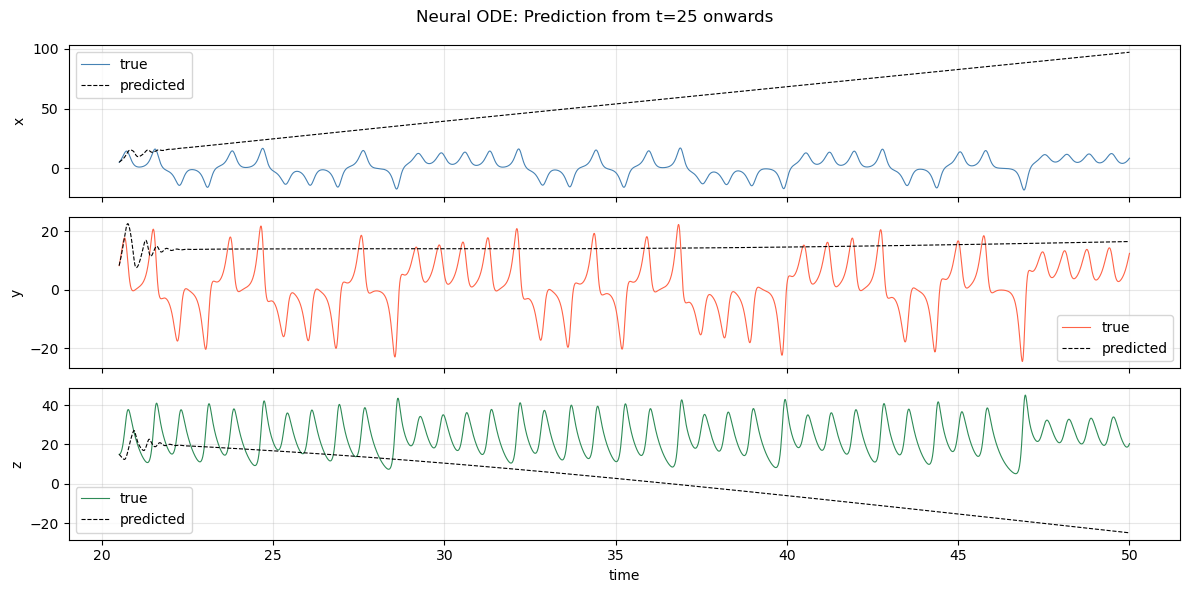

In [21]:
func.eval()
with torch.no_grad():
    # start prediction from t=25 (end of training window)
    u_pred_norm = odeint(func, traj_norm[end], t[end:], method='rk4').numpy()

# denormalize back
u_pred = u_pred_norm * std.numpy() + mean.numpy()
true   = traj[end:].numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t[end:], true[:, i],   lw=0.8, color=color, label='true')
    axes[i].plot(t[end:], u_pred[:, i], lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('Neural ODE: Prediction from t=25 onwards')
plt.tight_layout()
plt.savefig('neural_ode_prediction.png', dpi=150)
plt.show()


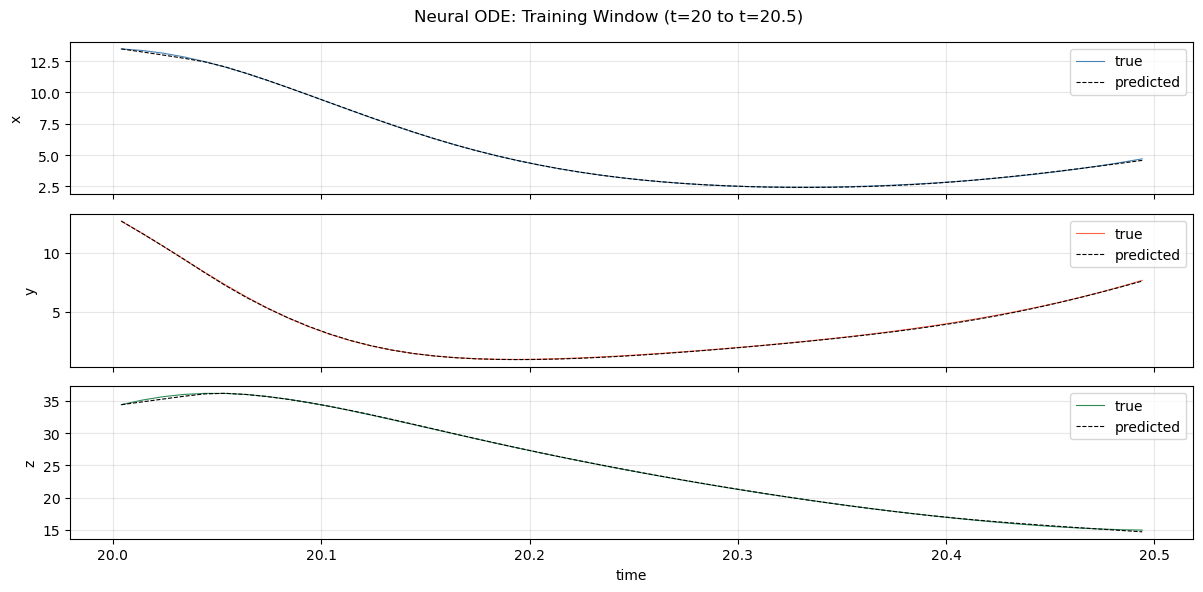

In [22]:
func.eval()
with torch.no_grad():
    u_pred_norm = odeint(func, traj_train[0], t_train, method='rk4').numpy()

u_pred = u_pred_norm * std.numpy() + mean.numpy()
true   = traj[start:end].numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t_train, true[:, i],   lw=0.8, color=color, label='true')
    axes[i].plot(t_train, u_pred[:, i], lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('Neural ODE: Training Window (t=20 to t=20.5)')
plt.tight_layout()
plt.savefig('neural_ode_training.png', dpi=150)
plt.show()

## Physics Informed Neural Network (PINN)


In [28]:
data = np.load('lorenz_data.npy')
t_all    = torch.tensor(data[:, 0], dtype=torch.float32)
traj_all = torch.tensor(data[:, 1:], dtype=torch.float32)

start = 2000  # t=20
end   = 2050  # t=20.5

t_window = t_all[start:end].unsqueeze(1).requires_grad_(True)
u_window = traj_all[start:end]

# 500 collocation points in [20, 20.5]
t_phys = (torch.rand(500, 1) * 0.5 + 20).requires_grad_(True)

sigma, rho, beta = 10.0, 28.0, 8/3


## Using PINN to learn the equation of a small part of the original Lorenz Trajectory

In [29]:
class PINN_Fourier(nn.Module):
    def __init__(self, n_freq=10):
        super().__init__()
        self.n_freq = n_freq
        self.net = nn.Sequential(
            nn.Linear(n_freq * 2, 64), nn.Tanh(),
            nn.Linear(64, 64),         nn.Tanh(),
            nn.Linear(64, 64),         nn.Tanh(),
            nn.Linear(64, 3)
        )
    def fourier(self, t):
        freqs = torch.arange(1, self.n_freq + 1).float()
        return torch.cat([torch.sin(freqs * t), torch.cos(freqs * t)], dim=1)
    def forward(self, t):
        return self.net(self.fourier(t))

model     = PINN_Fourier()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def physics_loss(t):
    u = model(t)
    x, y, z = u[:, 0], u[:, 1], u[:, 2]
    dx = torch.autograd.grad(x.sum(), t, create_graph=True)[0][:, 0]
    dy = torch.autograd.grad(y.sum(), t, create_graph=True)[0][:, 0]
    dz = torch.autograd.grad(z.sum(), t, create_graph=True)[0][:, 0]
    res_x = dx - sigma * (y - x)
    res_y = dy - x * (rho - z) + y
    res_z = dz - x * y + beta * z
    return (res_x**2 + res_y**2 + res_z**2).mean()

for epoch in range(5000):
    optimizer.zero_grad()
    loss_data = nn.MSELoss()(model(t_window), u_window)
    loss_phys = physics_loss(t_phys)
    loss = loss_data + loss_phys
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f'epoch {epoch}, data {loss_data.item():.4f}, phys {loss_phys.item():.4f}')


epoch 0, data 250.7387, phys 39.5573
epoch 1000, data 10.6292, phys 0.8344
epoch 2000, data 2.4872, phys 0.1438
epoch 3000, data 1.6233, phys 0.0818
epoch 4000, data 0.7525, phys 0.0676


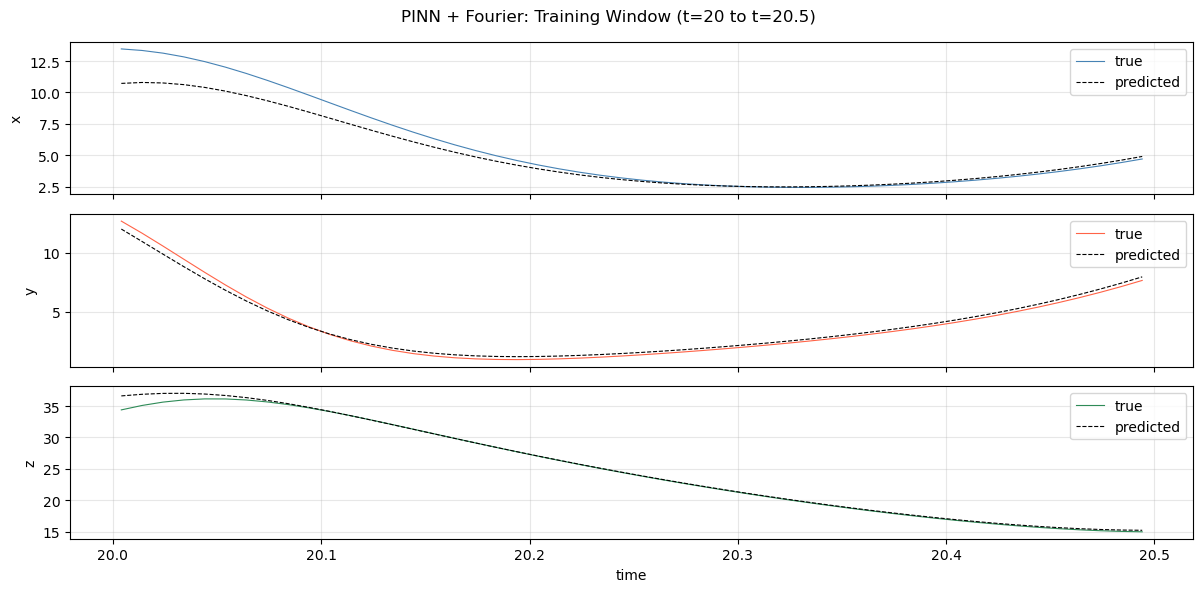

In [30]:
model.eval()
with torch.no_grad():
    t_plot = t_all[start:end].unsqueeze(1)
    u_pred = model(t_plot).numpy()

true = traj_all[start:end].numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t_all[start:end], true[:, i],   lw=0.8, color=color, label='true')
    axes[i].plot(t_all[start:end], u_pred[:, i], lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('PINN + Fourier: Training Window (t=20 to t=20.5)')
plt.tight_layout()
plt.savefig('pinn_fourier.png', dpi=150)
plt.show()


## Data points fitting
This part is using PINN to fit the original data point by memorizing a large scale of original data
Therefore, testing in what kind of way that the method will fit the data will, theoretically, the model will then
use the same method to learn the equation of Lorenz System

In [ ]:
# normalize t as well
t_mean = t_all.mean()
t_std  = t_all.std()
t_norm = (t_all - t_mean) / t_std

t_input = t_norm.unsqueeze(1).requires_grad_(True)
u_all_norm = (traj_all - traj_all.mean(dim=0)) / traj_all.std(dim=0)

sigma, rho, beta = 10.0, 28.0, 8/3

In [ ]:
model = PINN_Fourier(n_freq=20)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

# stage 1: just fit the data
for epoch in range(5000):
    optimizer.zero_grad()
    loss = nn.MSELoss()(model(t_input), u_all_norm)
    loss.backward()
    optimizer.step()
    scheduler.step()
    print(f'epoch {epoch}, loss {loss.item():.4f}')

epoch 0, loss 1.0032
epoch 1, loss 0.9881
epoch 2, loss 0.9735
epoch 3, loss 0.9589
epoch 4, loss 0.9440
epoch 5, loss 0.9287
epoch 6, loss 0.9128
epoch 7, loss 0.8961
epoch 8, loss 0.8787
epoch 9, loss 0.8606
epoch 10, loss 0.8420
epoch 11, loss 0.8232
epoch 12, loss 0.8047
epoch 13, loss 0.7870
epoch 14, loss 0.7709
epoch 15, loss 0.7571
epoch 16, loss 0.7462
epoch 17, loss 0.7386
epoch 18, loss 0.7341
epoch 19, loss 0.7322
epoch 20, loss 0.7316
epoch 21, loss 0.7313
epoch 22, loss 0.7303
epoch 23, loss 0.7284
epoch 24, loss 0.7257
epoch 25, loss 0.7227
epoch 26, loss 0.7197
epoch 27, loss 0.7173
epoch 28, loss 0.7156
epoch 29, loss 0.7146
epoch 30, loss 0.7140
epoch 31, loss 0.7136
epoch 32, loss 0.7133
epoch 33, loss 0.7127
epoch 34, loss 0.7119
epoch 35, loss 0.7107
epoch 36, loss 0.7093
epoch 37, loss 0.7077
epoch 38, loss 0.7061
epoch 39, loss 0.7046
epoch 40, loss 0.7033
epoch 41, loss 0.7021
epoch 42, loss 0.7012
epoch 43, loss 0.7005
epoch 44, loss 0.6998
epoch 45, loss 0.699

In [40]:
t_phys_norm = (torch.rand(5000, 1) * 50 - t_mean.item()) / t_std.item()
t_phys_norm.requires_grad_(True)

optimizer2 = torch.optim.Adam(model.parameters(), lr=1e-4)

def physics_loss_norm(t):
    u = model(t)
    # scale back to original
    u_orig = u * traj_all.std(dim=0) + traj_all.mean(dim=0)
    x, y, z = u_orig[:, 0], u_orig[:, 1], u_orig[:, 2]
    # dt_orig = dt_norm * t_std
    dx = torch.autograd.grad(x.sum(), t, create_graph=True)[0][:, 0] / t_std
    dy = torch.autograd.grad(y.sum(), t, create_graph=True)[0][:, 0] / t_std
    dz = torch.autograd.grad(z.sum(), t, create_graph=True)[0][:, 0] / t_std
    res_x = dx - sigma * (y - x)
    res_y = dy - x * (rho - z) + y
    res_z = dz - x * y + beta * z
    return (res_x**2 + res_y**2 + res_z**2).mean()

for epoch in range(5000):
    optimizer2.zero_grad()
    loss_data = nn.MSELoss()(model(t_input), u_all_norm)
    loss_phys = physics_loss_norm(t_phys_norm)
    loss = loss_data + 0.0001 * loss_phys
    loss.backward()
    optimizer2.step()
    print(f'epoch {epoch}, data {loss_data.item():.4f}, phys {loss_phys.item():.4f}')

epoch 0, data 0.0016, phys 183.5929
epoch 1, data 0.0032, phys 214.0672
epoch 2, data 0.0021, phys 185.3454
epoch 3, data 0.0021, phys 192.6050
epoch 4, data 0.0021, phys 192.9144
epoch 5, data 0.0020, phys 185.8695
epoch 6, data 0.0019, phys 178.0296
epoch 7, data 0.0019, phys 176.7720
epoch 8, data 0.0020, phys 179.3336
epoch 9, data 0.0021, phys 177.6811
epoch 10, data 0.0020, phys 172.5597
epoch 11, data 0.0019, phys 169.9197
epoch 12, data 0.0019, phys 171.1312
epoch 13, data 0.0019, phys 172.3466
epoch 14, data 0.0019, phys 171.0621
epoch 15, data 0.0018, phys 168.5302
epoch 16, data 0.0018, phys 166.6923
epoch 17, data 0.0019, phys 166.0581
epoch 18, data 0.0019, phys 165.9919
epoch 19, data 0.0019, phys 165.4983
epoch 20, data 0.0019, phys 164.1879
epoch 21, data 0.0019, phys 162.7892
epoch 22, data 0.0019, phys 162.2410
epoch 23, data 0.0019, phys 162.4144
epoch 24, data 0.0019, phys 162.3330
epoch 25, data 0.0018, phys 161.5106
epoch 26, data 0.0018, phys 160.3939
epoch 27, d

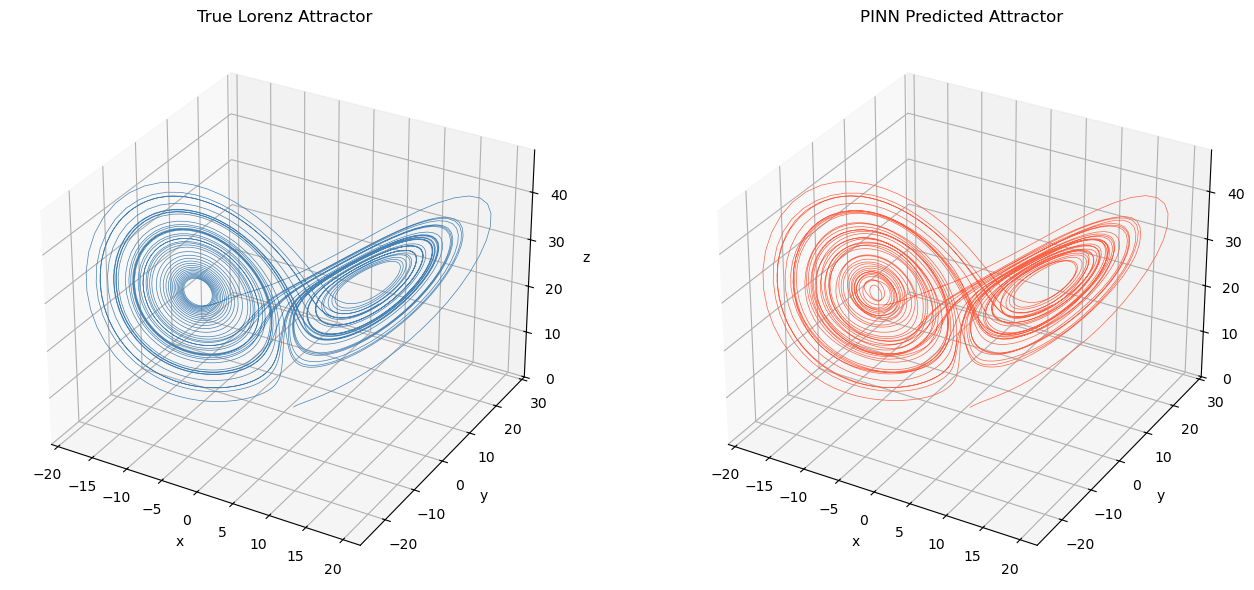

In [41]:
model.eval()
with torch.no_grad():
    u_pred_norm = model(t_norm.unsqueeze(1)).numpy()

u_pred = u_pred_norm * traj_all.std(dim=0).numpy() + traj_all.mean(dim=0).numpy()

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(traj_all[:, 0], traj_all[:, 1], traj_all[:, 2], lw=0.5, color='steelblue')
ax1.set_title('True Lorenz Attractor')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(u_pred[:, 0], u_pred[:, 1], u_pred[:, 2], lw=0.5, color='tomato')
ax2.set_title('PINN Predicted Attractor')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

plt.tight_layout()
plt.savefig('pinn_attractor.png', dpi=150)
plt.show()

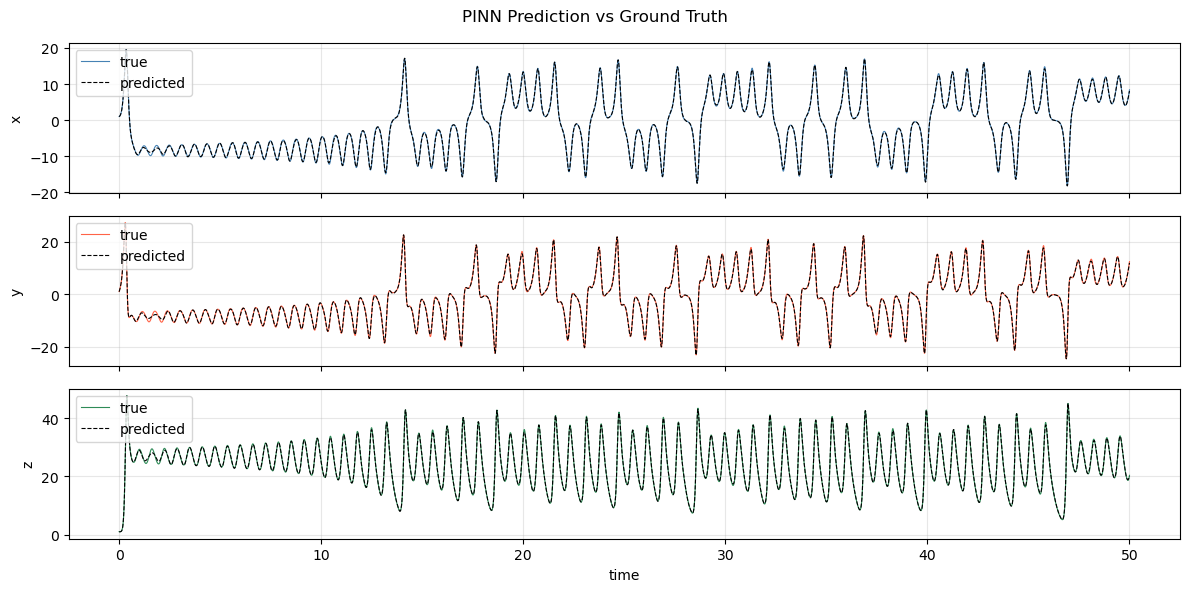

In [42]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t_all, traj_all[:, i],  lw=0.8, color=color, label='true')
    axes[i].plot(t_all, u_pred[:, i],    lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('PINN Prediction vs Ground Truth')
plt.tight_layout()
plt.savefig('pinn_xyz.png', dpi=150)
plt.show()

As the images displayed, using a two stage loss, the fitting was perfect, so by analogy, I used the same method on model training for PINN

## System Prediction

In [43]:
# train on first 1000 points (t=0 to t=10)
train_end = 1000

t_train_raw = t_all[:train_end]
u_train_raw = traj_all[:train_end]

# normalize
t_mean = t_train_raw.mean()
t_std  = t_train_raw.std()
u_mean = u_train_raw.mean(dim=0)
u_std  = u_train_raw.std(dim=0)

t_train_norm = ((t_train_raw - t_mean) / t_std).unsqueeze(1).requires_grad_(True)
u_train_norm = (u_train_raw - u_mean) / u_std

# collocation points only in training window
t_phys_norm = ((torch.rand(2000, 1) * 10) - t_mean) / t_std
t_phys_norm.requires_grad_(True)

sigma, rho, beta = 10.0, 28.0, 8/3

In [44]:
model = PINN_Fourier(n_freq=20)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

for epoch in range(5000):
    optimizer.zero_grad()
    loss = nn.MSELoss()(model(t_train_norm), u_train_norm)
    loss.backward()
    optimizer.step()
    scheduler.step()
    if epoch % 1000 == 0:
        print(f'epoch {epoch}, loss {loss.item():.4f}')

epoch 0, loss 1.0197
epoch 1000, loss 0.0001
epoch 2000, loss 0.0000
epoch 3000, loss 0.0000
epoch 4000, loss 0.0000


In [46]:
optimizer2 = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5000):
    optimizer2.zero_grad()
    loss_data = nn.MSELoss()(model(t_train_norm), u_train_norm)
    loss_phys = physics_loss_norm(t_phys_norm)
    loss = loss_data + 0.0001 * loss_phys
    loss.backward()
    optimizer2.step()
    print(f'epoch {epoch}, data {loss_data.item():.4f}, phys {loss_phys.item():.4f}')

epoch 0, data 0.2561, phys 836.2196
epoch 1, data 0.2567, phys 828.2402
epoch 2, data 0.2542, phys 853.8228
epoch 3, data 0.2565, phys 829.5164
epoch 4, data 0.2567, phys 826.9925
epoch 5, data 0.2563, phys 830.0494
epoch 6, data 0.2559, phys 833.0074
epoch 7, data 0.2557, phys 835.1835
epoch 8, data 0.2555, phys 835.9514
epoch 9, data 0.2556, phys 834.5450
epoch 10, data 0.2558, phys 831.2195
epoch 11, data 0.2561, phys 827.8444
epoch 12, data 0.2561, phys 827.2254
epoch 13, data 0.2558, phys 829.9684
epoch 14, data 0.2554, phys 833.5693
epoch 15, data 0.2552, phys 834.6492
epoch 16, data 0.2554, phys 832.1288
epoch 17, data 0.2558, phys 828.1128
epoch 18, data 0.2560, phys 825.5562
epoch 19, data 0.2559, phys 825.7503
epoch 20, data 0.2557, phys 827.6571
epoch 21, data 0.2554, phys 829.2526
epoch 22, data 0.2554, phys 829.5069
epoch 23, data 0.2554, phys 828.7731
epoch 24, data 0.2554, phys 827.7515
epoch 25, data 0.2555, phys 826.6552
epoch 26, data 0.2556, phys 825.4460
epoch 27, d

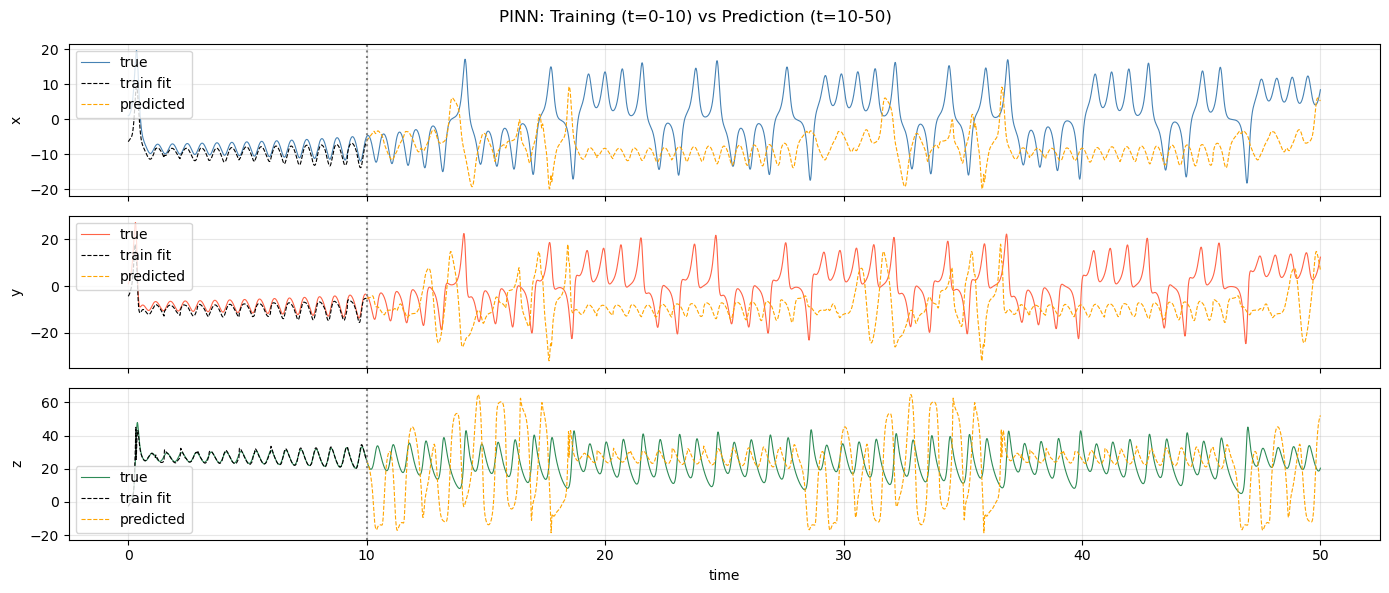

In [49]:
model.eval()
with torch.no_grad():
    # training window
    t_train_plot = ((t_all[:train_end] - t_mean) / t_std).unsqueeze(1)
    u_train_pred = model(t_train_plot).numpy() * u_std.numpy() + u_mean.numpy()

    # prediction window
    t_pred_plot  = ((t_all[train_end:] - t_mean) / t_std).unsqueeze(1)
    u_pred       = model(t_pred_plot).numpy() * u_std.numpy() + u_mean.numpy()

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    # true
    axes[i].plot(t_all, traj_all[:, i], lw=0.8, color=color, label='true')
    # training fit
    axes[i].plot(t_all[:train_end], u_train_pred[:, i], lw=0.8, color='black', linestyle='--', label='train fit')
    # prediction
    axes[i].plot(t_all[train_end:], u_pred[:, i], lw=0.8, color='orange', linestyle='--', label='predicted')
    # dividing line
    axes[i].axvline(x=10, color='gray', linestyle=':', lw=1.5)
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('time')
plt.suptitle('PINN: Training (t=0-10) vs Prediction (t=10-50)')
plt.tight_layout()
plt.savefig('pinn_prediction_full.png', dpi=150)
plt.show()

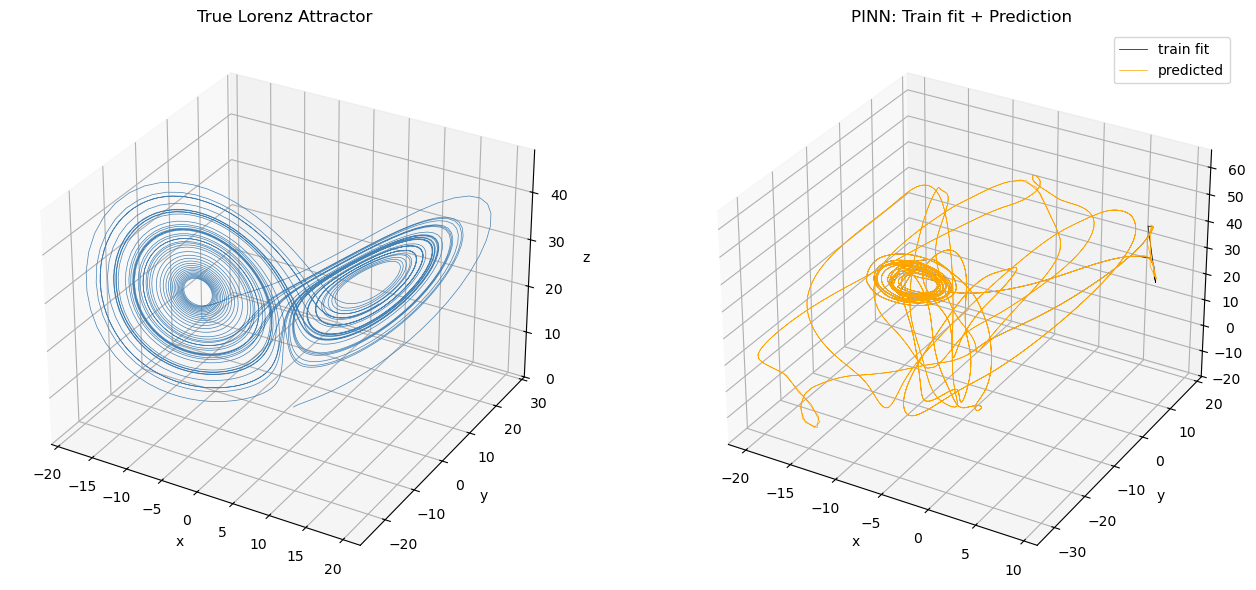

In [51]:
fig = plt.figure(figsize=(14, 6))

# true attractor
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(traj_all[:, 0], traj_all[:, 1], traj_all[:, 2], lw=0.5, color='steelblue')
ax1.set_title('True Lorenz Attractor')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# pinn predicted
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(u_train_pred[:, 0], u_train_pred[:, 1], u_train_pred[:, 2], lw=0.5, color='black', label='train fit')
ax2.plot(u_pred[:, 0],       u_pred[:, 1],       u_pred[:, 2],       lw=0.5, color='orange', label='predicted')
ax2.set_title('PINN: Train fit + Prediction')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
ax2.legend()

plt.tight_layout()
plt.savefig('pinn_attractor_pred.png', dpi=150)
plt.show()